<a href="https://colab.research.google.com/github/febriyansyah-id/COLLAB/blob/main/notebooks/NLP-assignment-P02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP Assignment P02
## Pengujian Library Python untuk NLP

Notebook ini dijalankan di Google Colab untuk menguji library fondasional dan modern yang digunakan dalam Natural Language Processing.

### Tujuan

- Memeriksa ketersediaan library NLP.
- Menjalankan fungsi dasar setiap library wajib.
- Mencatat library yang berhasil, dilewati, atau gagal.
- Membandingkan peran library dalam pipeline NLP.

## 1. Instalasi dependency di Google Colab

Colab sudah menyediakan NumPy, pandas, SciPy, Matplotlib, scikit-learn, dan PyTorch. Package tambahan dipasang pada cell berikut.

In [17]:
%pip install -q nltk spacy transformers datasets tokenizers sentence-transformers langdetect Sastrawi seaborn regex

## 2. Menjalankan program pengujian

Notebook ini diasumsikan dijalankan dari root repository `COLLAB`. Jika repository belum tersedia di Colab, clone terlebih dahulu menggunakan GitHub.

In [18]:
from pathlib import Path

script = Path('projects/nlp/NLP-assignment-P02/NLP-assignment-P02.py')
if not script.exists():
    print('Script belum ditemukan. Clone repository COLLAB terlebih dahulu.')
else:
    print(f'Script ditemukan: {script}')

Script belum ditemukan. Clone repository COLLAB terlebih dahulu.


In [19]:
!python projects/nlp/NLP-assignment-P02/NLP-assignment-P02.py

python3: can't open file '/content/projects/nlp/NLP-assignment-P02/NLP-assignment-P02.py': [Errno 2] No such file or directory


## 3. Analisis hasil

Tuliskan hasil pengamatan setelah menjalankan program:

1. Library mana yang berstatus `PASS`?
2. Apakah ada library berstatus `SKIP` atau `FAIL`? Jelaskan penyebabnya.
3. Library mana yang paling mudah digunakan untuk pemrosesan teks dasar?
4. Apa perbedaan NLTK, spaCy, scikit-learn, dan Transformers?
5. Mengapa Sastrawi penting untuk teks bahasa Indonesia?

## 4. Kesimpulan

Tuliskan jumlah `PASS`, `SKIP`, dan `FAIL`, kemudian jelaskan library yang paling sesuai untuk proyek NLP berikutnya.

## 5. Praktik langsung library wajib

Bagian berikut menjalankan contoh kecil secara langsung di notebook.

In [20]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

texts = [
    'Python digunakan untuk pengolahan bahasa alami',
    'NLP membantu komputer memahami teks manusia',
    'Model machine learning dapat mengklasifikasikan dokumen',
]
data = pd.DataFrame({'text': texts, 'label': ['programming', 'nlp', 'machine-learning']})
data

,text,label
0,Python digunakan untuk pengolahan bahasa alami,programming
1,NLP membantu komputer memahami teks manusia,nlp
2,Model machine learning dapat mengklasifikasika...,machine-learning


In [21]:
# NumPy, regex, dan TF-IDF dengan scikit-learn
clean_texts = [re.sub(r'[^a-zA-Z\s]', '', text.lower()) for text in data['text']]
vectorizer = TfidfVectorizer()
tfidf = vectorizer.fit_transform(clean_texts)
print('Shape TF-IDF:', tfidf.shape)
print('Vocabulary:', vectorizer.get_feature_names_out())
print('Rata-rata nilai fitur:', np.asarray(tfidf.mean(axis=0)).round(3))

Shape TF-IDF: (3, 18)
Vocabulary: ['alami' 'bahasa' 'dapat' 'digunakan' 'dokumen' 'komputer' 'learning'
 'machine' 'manusia' 'memahami' 'membantu' 'mengklasifikasikan' 'model'
 'nlp' 'pengolahan' 'python' 'teks' 'untuk']
Rata-rata nilai fitur: [[0.136 0.136 0.136 0.136 0.136 0.136 0.136 0.136 0.136 0.136 0.136 0.136
  0.136 0.136 0.136 0.136 0.136 0.136]]


In [22]:
# NLTK dan spaCy
import nltk
from nltk.tokenize import wordpunct_tokenize
import spacy

sample = 'Saya sedang belajar Natural Language Processing.'
print('NLTK:', wordpunct_tokenize(sample))
nlp = spacy.blank('id')
print('spaCy:', [token.text for token in nlp(sample)])

NLTK: ['Saya', 'sedang', 'belajar', 'Natural', 'Language', 'Processing', '.']
spaCy: ['Saya', 'sedang', 'belajar', 'Natural', 'Language', 'Processing', '.']


In [23]:
# Sastrawi untuk stemming bahasa Indonesia
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
stemmer = StemmerFactory().create_stemmer()
sentence = 'Pemerintah sedang meningkatkan pelayanan masyarakat'
print('Kalimat:', sentence)
print('Hasil stemming:', stemmer.stem(sentence))

Kalimat: Pemerintah sedang meningkatkan pelayanan masyarakat
Hasil stemming: perintah sedang tingkat layan masyarakat


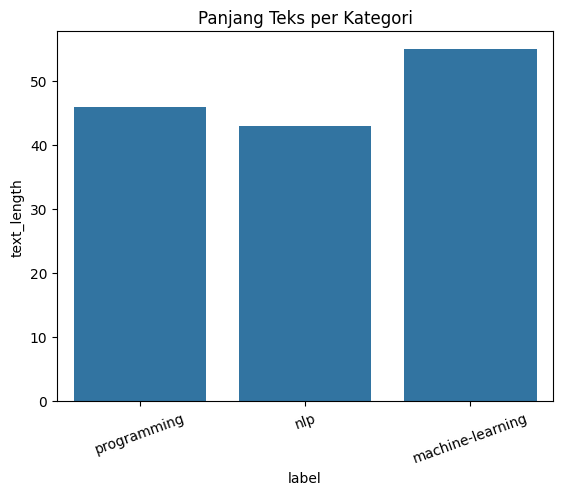

In [24]:
# Visualisasi sederhana distribusi panjang teks
data['text_length'] = data['text'].str.len()
sns.barplot(data=data, x='label', y='text_length')
plt.xticks(rotation=20)
plt.title('Panjang Teks per Kategori')
plt.show()

## 6. Interpretasi

Jelaskan apa yang dilakukan setiap library pada cell praktik dan hubungkan hasilnya dengan pipeline NLP: preprocessing, tokenisasi, representasi fitur, model, dan visualisasi.